# Анализ взаимосвязи ожидаемой продолжительности жизни и ВВП на душу населения

### Цель исследования - ответить на вопросы: 
* Как связаны между собой ожидаемая продолжительность жизни и ВВП на душу населения по странам мира?
* Какое распределения имеют страны мира по ВВП на душу населения?
* Какой континент является лидером по данным показателям?
* Что различает Европу и Азию в контексте продолжительности жизни и ВВП на душу населения?

### Ход исследования
1. Импорт данных о ВВП на душу населения, предобработка, краткие выводы
2. Импорт данных об ожидаемой продолжительности жизни, предобработка, краткие выводы
3. Выводы

## 1. Импорт данных о ВВП

##### Исследуем данные о ВВП на душу населения по странам мира и его влияние на ожидаемую продолжительность жизни в 2025 году с помощью языка Python и его библиотек.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv(r"C:\Users\NikolaySanin\Desktop\gdp-per-capita-by-country-2025.csv")

In [46]:
data.head()

,flagCode,country,GDPPerCapitaViaIMF_2025,GDPPerCapitaViaUN_2023
0,LU,Luxembourg,141079.52,128935.90
1,CH,Switzerland,111716.02,100830.69
2,IE,Ireland,107243.00,106106.24
3,SG,Singapore,93956.01,86615.97
4,NO,Norway,90320.01,87931.90


In [47]:
data.rename(columns={"GDPPerCapitaViaIMF_2025":"IMF_2025", "GDPPerCapitaViaUN_2023":"UN_2023"}, inplace=True)
data.drop('flagCode', axis=1, inplace=True)
data.rename(lambda x: x+1, axis=0, inplace=True)

##### IMF_2025 - ВВП на душу населения по странам мира на 2025 год по данным Международного Валютного Фонда, долл. США

##### UN_2023 - ВВП на душу населения по странам мира на 2023 год по данным Организации Объединных Наций, долл. США

##### Источник: https://worldpopulationreview.com/country-rankings/gdp-per-capita-by-country.

##### Также удалим все знаки после запятой в обоих столбцах, а прежде удалим строки с пропущенными значениями.

In [48]:
def del_signs(number):
    number_int = int(number)
    return number_int

data.dropna(inplace=True)
data['IMF_2025'] = data['IMF_2025'].apply(del_signs)
data['UN_2023'] = data['UN_2023'].apply(del_signs)
data.head()

,country,IMF_2025,UN_2023
1,Luxembourg,141079,128935
2,Switzerland,111716,100830
3,Ireland,107243,106106
4,Singapore,93956,86615
5,Norway,90320,87931


##### Посмотрим, насколько сильна корреляция между данными МВФ и ООН (пусть за разные годы). Сначала посмотрим на диаграмму scatterplot.
##### Как мы можем видеть по графику, это сильная прямая линейная корреляция.

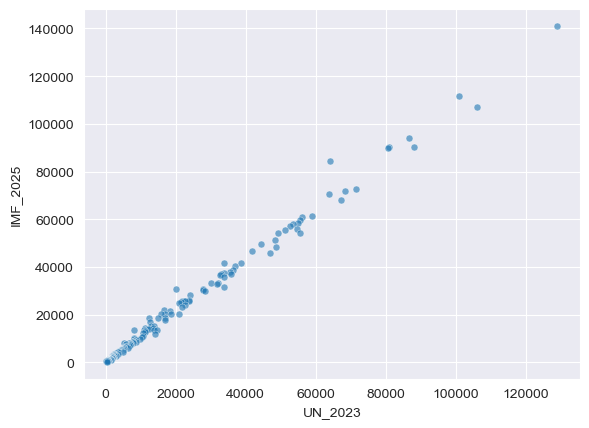

In [49]:
sns.set_style('darkgrid')
sns.scatterplot(x=data['UN_2023'], y=data['IMF_2025'], alpha=0.6, s=25);

##### Далее вычислим коэффициент корреляции, который, конечно, подтвердит тесную взаимосвязь:

In [50]:
data['UN_2023'].corr(data['IMF_2025'])

0.9967149871098178

##### А также выведем основные статистические показатели по ряду данных от МВФ (далее будем работать с этим столбцом):

In [51]:
data['IMF_2025'].describe()

count       187.000000
mean      19505.245989
std       25063.971270
min         156.000000
25%        2837.000000
50%        8002.000000
75%       25965.000000
max      141079.000000
Name: IMF_2025, dtype: float64

##### Далее покажем диаграмму KDE - ядерную оценку плотности. По смыслу это аналог столбчатой диаграммы, но вместо столбцов - сглаженная кривая

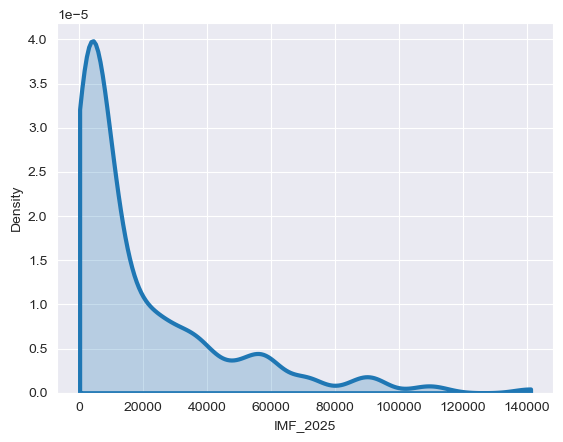

In [52]:
sns.kdeplot(x=data['IMF_2025'], fill=True, linewidth=3, cut=0, bw_method=0.2);

##### А теперь и сама гистограмма. Из нее мы видим, что больше 60% наблюдений входят в интервал от 0 до 20000$ по ВВП на душу населения:

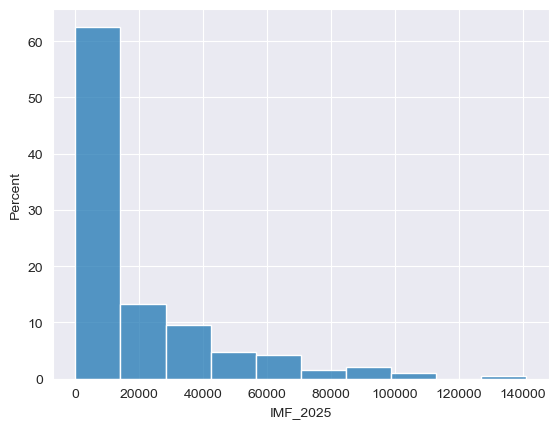

In [53]:
sns.histplot(x=data['IMF_2025'], bins=10, stat='percent');

##### Выведем также функцию ECDF, показывающую долю числа наблюдений, меньших, либо равных данному наблюдению:
##### Например, на графике ниже видно, что примерно в 70% странах мира ВВП на душу населения меньше, чем 20000$.

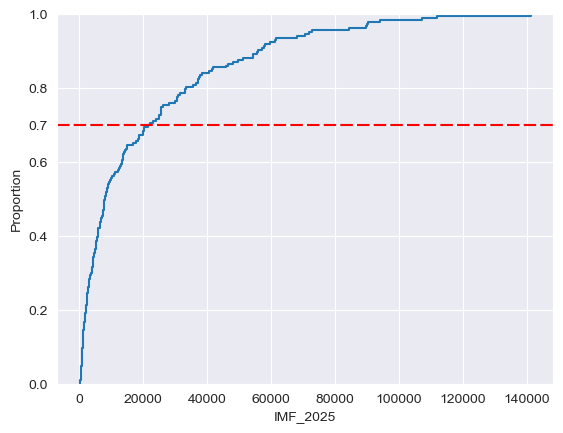

In [54]:
sns.ecdfplot(x=data['IMF_2025']);

plt.axhline(0.7, color='r', linestyle='--', dashes=(6,2)) #Добавим горизонтальную линию
yticks = plt.yticks()[0] #Добавим отметку данных к этой линии
new_yticks = list(yticks) + [0.7]
plt.yticks(new_yticks);

##### Для более детального исследования добавим к каждой стране ее континент

##### Источник: https://worldpopulationreview.com/country-rankings/list-of-countries-by-continent

In [55]:
continents = pd.read_csv(r"C:\Users\NikolaySanin\Desktop\list-of-countries-by-continent-2025.csv")

In [56]:
continents.head()

,flagCode,country,continent,unMember
0,AF,Afghanistan,Asia,True
1,AL,Albania,Europe,True
2,DZ,Algeria,Africa,True
3,AS,American Samoa,Oceania,False
4,AD,Andorra,Europe,True


##### Удалим ненужные столбцы:

In [57]:
continents.drop(['flagCode', 'unMember'], axis=1, inplace=True)

In [58]:
continents.head()

,country,continent
0,Afghanistan,Asia
1,Albania,Europe
2,Algeria,Africa
3,American Samoa,Oceania
4,Andorra,Europe


##### Объединим две таблицы:

In [59]:
data = data.merge(continents, on='country', how='inner')

##### Переместим последний столбец continent на первое место и немного переименуем столбцы:

In [60]:
data = data.iloc[:, [3,0,1,2]]
data.rename(columns={"continent":"continent", "country":"country", "IMF_2025":"IMF_25", "UN_2023":"UN_23"}, inplace=True)

##### Покажем средние величины данных в разрезе частей света, заметим, что у какой-то страны отмечено сразу два значения - Азия и Европа:

In [61]:
data[['continent', 'IMF_25']].groupby(by='continent').mean()

,IMF_25
continent,
Africa,3062.698113
Asia,19742.047619
"Asia, Europe",15077.000000
Europe,43717.536585
North America,21219.500000
Oceania,14177.214286
South America,11728.916667


##### Оказывается, это Россия. Исправим это: заменим ее континент на значение "Europe".

In [62]:
data.query('continent == "Asia, Europe"')

,continent,country,IMF_25,UN_23
67,"Asia, Europe",Russia,15077,13809


##### Теперь количество значений континентов на единицу меньше:

In [63]:
data.loc[data['country'] == 'Russia', 'continent'] = 'Europe'
pd.unique(data['continent'])

array(['Europe', 'Asia', 'North America', 'Oceania', 'South America',
       'Africa'], dtype=object)

## 2. Импорт данных об ожидаемой продолжительности жизни

##### Добавим еще новые данные: среднюю продолжительность жизни по странам мира. Эти данные будут за 2024 год, но будем считать их примерно равными данным за 2025-й.

##### Средняя продолжительность жизни по странам мира по состоянию на 2024 год:
##### Источник: https://worldpopulationreview.com/country-rankings/life-expectancy-by-countr

In [64]:
life_exp = pd.read_csv(r"C:\Users\NikolaySanin\Desktop\life-expectancy-by-country-2025.csv")

##### Данные представлены в разрезе пола, но мы возьмем общий показатель. Удалим три ненужных столбца (еще и flagCode).

In [65]:
life_exp.head(3)

,flagCode,country,LifeExpectancyViaUN_2024,LifeExpectancyFemalesUN_2024,LifeExpectancyMalesUN_2024
0,MC,Monaco,86.50,88.63,84.56
1,SM,San Marino,85.82,87.22,84.32
2,HK,Hong Kong,85.63,88.26,82.97


In [66]:
life_exp.drop(['flagCode', 'LifeExpectancyFemalesUN_2024', 'LifeExpectancyMalesUN_2024'], axis=1, inplace=True)

##### Объединим датафрейм data и датафрейм life_exp по столбцу country. Также удалим столбец с прогнозами от ООН: мы его больше использовать не будем.

In [67]:
data = data.merge(life_exp, on='country', how='inner')
data.drop('UN_23', axis=1, inplace=True)

In [68]:
data.rename(columns={"LifeExpectancyViaUN_2024":"life_exp"}, inplace=True)
data.head(3)

,continent,country,IMF_25,life_exp
0,Europe,Luxembourg,141079,82.36
1,Europe,Switzerland,111716,84.09
2,Europe,Ireland,107243,82.58


##### Посмотрим на агрегированные статистические значения по ВВП и продолжительности жизни в разрезе континентов:

In [69]:
data[['continent', 'IMF_25']].groupby('continent').describe()

IMF_25                                                         \
               count          mean           std     min       25%      50%   
continent                                                                     
Africa          53.0   3062.698113   3743.621774   156.0    933.00   1687.0   
Asia            42.0  19742.047619  23700.997942   455.0   3643.75   8359.0   
Europe          42.0  43035.619048  30991.380606  5758.0  22437.50  34860.0   
North America   24.0  21219.500000  19968.744088  2434.0   8225.75  14095.5   
Oceania         14.0  14177.214286  19597.267079  2299.0   3887.50   6153.0   
South America   12.0  11728.916667   8329.831292  4120.0   6713.75   8232.5   

                                   
                    75%       max  
continent                          
Africa          4396.00   22001.0  
Asia           31232.25   93956.0  
Europe         58164.50  141079.0  
North America  25692.25   89677.0  
Oceania        12034.25   67978.0  
South America  13521.25   30650.0

In [70]:
data[['continent', 'life_exp']].groupby('continent').describe()

life_exp                                                        \
                 count       mean       std    min      25%     50%      75%   
continent                                                                      
Africa            53.0  65.588868  5.200887  54.63  62.1100  65.700  68.4900   
Asia              42.0  76.073333  5.183060  67.10  71.9450  75.215  80.5125   
Europe            42.0  80.142619  3.454169  71.33  77.3225  81.660  82.5725   
North America     24.0  74.989167  3.993470  65.12  72.6375  74.290  76.8175   
Oceania           14.0  70.516429  6.044748  62.28  67.1250  68.420  71.7850   
South America     12.0  75.509167  3.674478  68.74  73.4875  76.780  77.9175   

                      
                 max  
continent             
Africa         76.71  
Asia           85.63  
Europe         85.82  
North America  82.72  
Oceania        84.07  
South America  81.36

##### Исследуем зависимость подушевого ВВП от ожидаемой продолжительности жизни в разрезе континентов на точечной диаграмме.

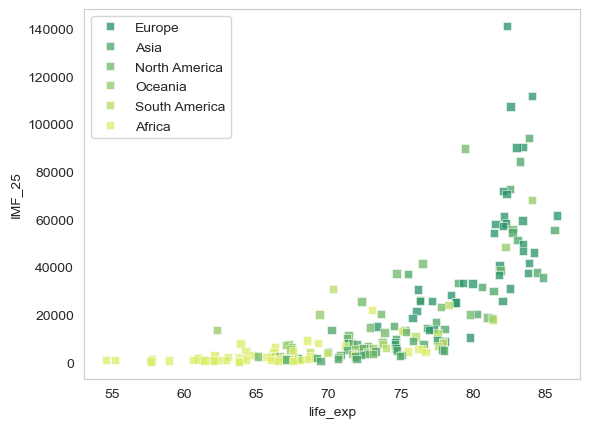

In [71]:
sns.set_style('whitegrid', {"axes.grid":"False"})
sns.scatterplot(x=data['life_exp'], y=data['IMF_25'], hue=data['continent'], marker='s', palette='summer', alpha=0.75);
plt.legend(loc='upper left');

##### Получим коэффициент корреляции между продолжительностью жизни и подушевым ВВП. По нему мы можем сказать, что корреляция между продолжительностью жизни и подушевым ВВП прямая по направлению и высокая по силе (но граничит со средней)

In [72]:
data['IMF_25'].corr(data['life_exp'])

0.7004034456319739

##### Далее визуализируем данные о ВВП в виде диаграммы Boxplot "Ящик с усами". По нему видим, что выбросами можем считать те данные, которые превышают отметку в 60 000$

<Axes: ylabel='IMF_25'>

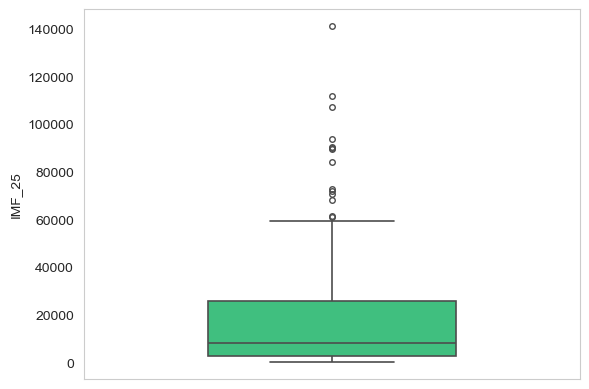

In [73]:
sns.boxplot(data['IMF_25'], width=0.5, color='SpringGreen', saturation=0.5, linewidth=1.2, fliersize=4);

##### Также покажем распределение данных на диаграмме violinplot, которая объединяет в себе boxplot и kde-диаграмму. По ней также отчетливо видно, что подавляющее большинство наблюдений концентрируется в районе небольших показателей ВВП (0-20000$):

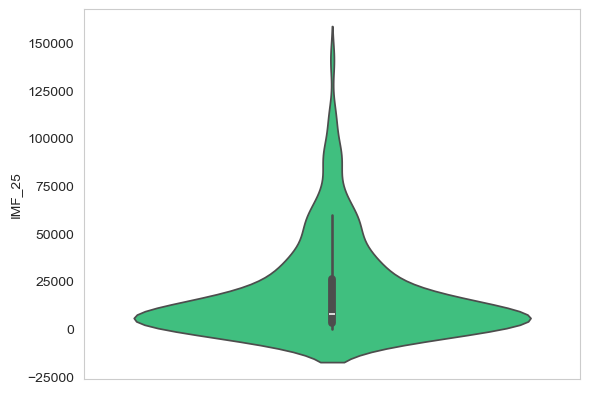

In [74]:
sns.violinplot(data['IMF_25'], color='SpringGreen', saturation=0.5);

##### Оставим в нашем датафрейме только те данные, которые соответствуют Европе и Азии, далее будем рассматривать только их.

In [75]:
proper_continents = ['Europe', 'Asia']
data = data.query('continent in @proper_continents')
data = data.reset_index()
data.drop('index', axis=1, inplace=True)

##### Таким образом, осталось всего два значения для столбца continent:

In [76]:
pd.unique(data['continent'])

array(['Europe', 'Asia'], dtype=object)

##### Далее воспользуемся диаграммой lmplot (linear model plot). Рассмотрим зависимость подушевого ВВП от ожидаемой продолжительности жизни. На данной точечной диаграмме в разрезе частей света отмечены линии тренда с доверительными интервалами = 95%. Отсюда можем наблюдать не только то, что оба показателя в Европе в среднем выше, но и то, что они более тесно связаны.

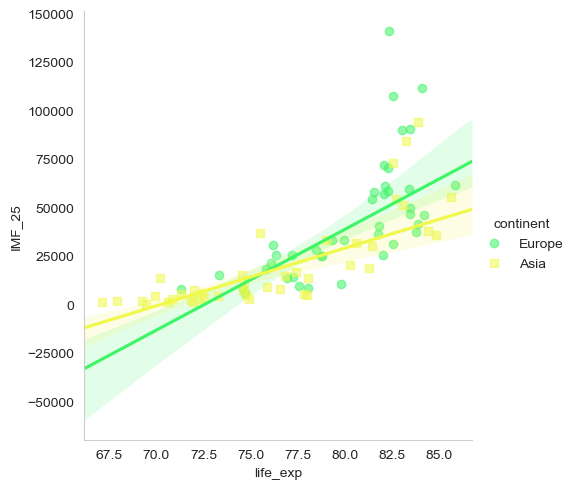

In [77]:
colors = ['#3df565', '#f0f84a']
sns.lmplot(data=data, y='IMF_25', x='life_exp', 
           hue='continent', 
           palette=colors, 
           markers=['o', 's'],
           scatter_kws={"alpha" : 0.55},
           truncate=False, 
           ci=95, 
           robust=True);

##### Теперь посмотрим на возможности диаграммы regplot: используем полиномиальную регрессию. Данная модель хороша тем, что имеет возможность более точно описывать сложные закономерности, но также необходимо помнить о переобучаемости модели (в нашем случае это может быть установка слишком высокой степени)

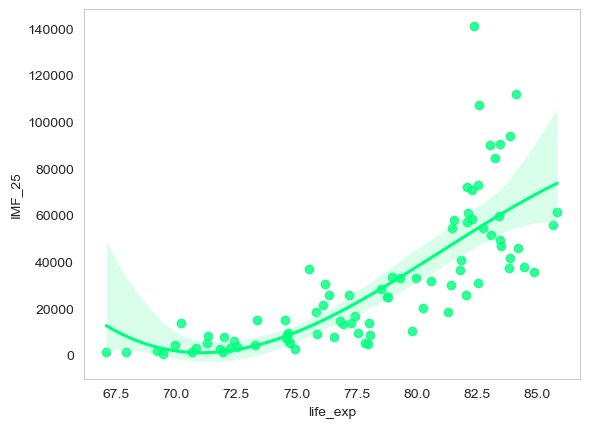

In [128]:
colors = ['#3df565', '#f0f84a']
#Полиномиальная регрессионная модель степени 3:
sns.regplot(data=data, x='life_exp', y='IMF_25',
           color='SpringGreen',
           order=3,
           ci=95);

In [79]:
data.head()

,continent,country,IMF_25,life_exp
0,Europe,Luxembourg,141079,82.36
1,Europe,Switzerland,111716,84.09
2,Europe,Ireland,107243,82.58
3,Asia,Singapore,93956,83.86
4,Europe,Norway,90320,83.46


##### Разобьем все страны мира на 3 категории: богатые, средние, бедные. Будем считать, что богатые - у кого ВВП на душу населения >= 35000 долл. Средние - у кого >= 10000 долл. Остальные - бедные. Для начала сменим тип столбца IMF-25 (по которому и будем определять уровень) на int64:

In [80]:
data['IMF_25'].astype('int64');

In [81]:
data.loc[data['IMF_25'] >= 35000, 'wealth' ] = 'богатые'
data.loc[(data['IMF_25'] < 35000) & (data['IMF_25'] >= 10000), 'wealth'] = 'средние'
data.loc[data['IMF_25'] < 10000, 'wealth'] = 'бедные'

##### Далее построим сводную таблицы по полученным данным:

In [82]:
data_pivot = data.pivot_table(index='continent', columns='wealth', values='IMF_25', aggfunc='count')
data_pivot = data_pivot[['бедные', 'средние', 'богатые']]

##### Seaborn располагает возможностью построить тепловую карту с количеством стран в каждой из подкатегорий (в разрезе континента и уровня богатства). С помощью данной heatmap вновь удостоверимся, что стран со средним и высоким подушевым ВВП в Европе больше, чем в Азии как в абсолютном, так и в относительном отношениях (к слову, количество стран в Европе и Азии в нашем датасете поровну - 42 и 42)

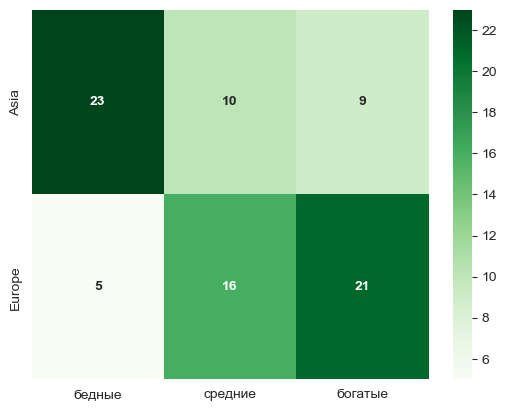

In [83]:
sns.heatmap(data_pivot, cmap='Greens', annot=True, annot_kws={'fontweight':'bold', 'fontsize':'10'});
plt.xlabel('');
plt.ylabel('');

##### Посмотрим на класс JointGrid, который позволяет увидеть распределение данных по обеим осям на одном графике. Возьмем зависимость ожидаемой продолжительности жизни от подушевого ВВП страны.

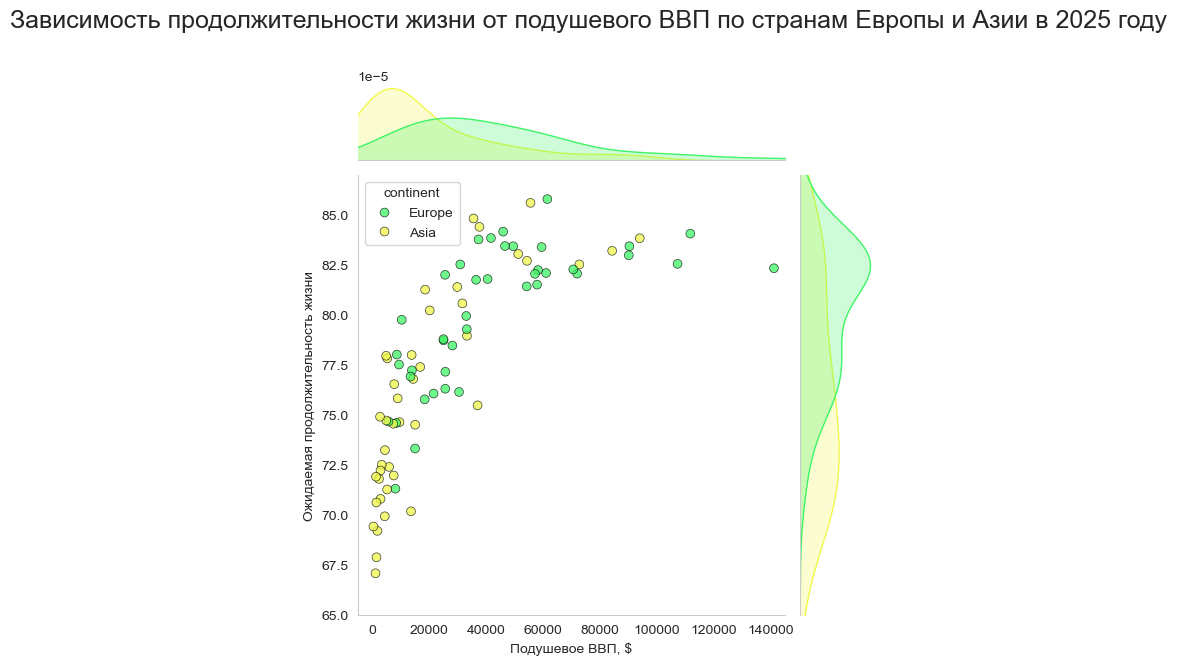

In [124]:
colors = ['#3df565', '#f0f84a']
g = sns.JointGrid(data=data, x='IMF_25', y='life_exp', xlim=[-5000, 145000], ylim=[65, 87], hue='continent', palette=colors)
g.plot_joint(sns.scatterplot, edgecolor='black', alpha=0.75, s=40);
g.plot_marginals(sns.kdeplot, fill=True);
g.set_axis_labels(xlabel='Подушевое ВВП, $', ylabel='Ожидаемая продолжительность жизни');
g.fig.suptitle('Зависимость продолжительности жизни от подушевого ВВП по странам Европы и Азии в 2025 году',y = 1.1, fontsize=18);

## 3. Выводы: 
* Корреляция между подушевым ВВП страны и её ожидаемой продолжительностью жизни прямая по направлению и высокая (почти средняя) по силе.
* Около 65% стран мира имеют ВВП на душу населения в районе 0-20000$.
* Наиболее высокими показателями в отношении ВВП и продолжительности жизни среди всех частей света обладает Европа, в которой подавляющее большинство стран являются средними или богатыми по части подушевого ВВП (в среднем 43000 долл. США по ВПП и средняя продолжительность жизни - 80 лет).
* Обратная картина наблюдается в Азии и других частях света, где большинство стран можно назвать бедными (по Азии: в среднем 20000 долл. США по ВВП и средняя продолжительность жизни - 76 лет).